In [1]:
import numpy as np
import pandas as pd

In [2]:
# 1) Load your data
df = pd.read_csv("scenecut_info.csv")


In [3]:
# camera cut times
camera_times = df["shot_start_t"].values

# scene cut times: when scene_id changes
scene_times = df.loc[df["scene_id"].diff().fillna(1) != 0, "shot_start_t"].values

# 2) Build time axis
movie_length = df["shot_start_t"].max() + df["shot_dur_t"].max()
dt = 0.3
times = np.arange(0, movie_length + dt, dt)   # include endpoint

# 3) Make impulse trains
camera_impulse = np.zeros_like(times)
scene_impulse  = np.zeros_like(times)
for t in camera_times:
    idx = int(np.round(t / dt))
    if idx < len(camera_impulse):
        camera_impulse[idx] = 1
for t in scene_times:
    idx = int(np.round(t / dt))
    if idx < len(scene_impulse):
        scene_impulse[idx] = 1

# 4) Build a linear‐decay kernel of 3 seconds
decay_secs = 3
kernel_len = int(np.ceil(decay_secs / dt))
decay_kernel = np.linspace(1, 0, kernel_len + 1)

# 5) Convolve and trim
camera_signal = np.convolve(camera_impulse, decay_kernel, mode="full")[:len(times)]
scene_signal  = np.convolve(scene_impulse,  decay_kernel, mode="full")[:len(times)]

(0.0, 200.0)

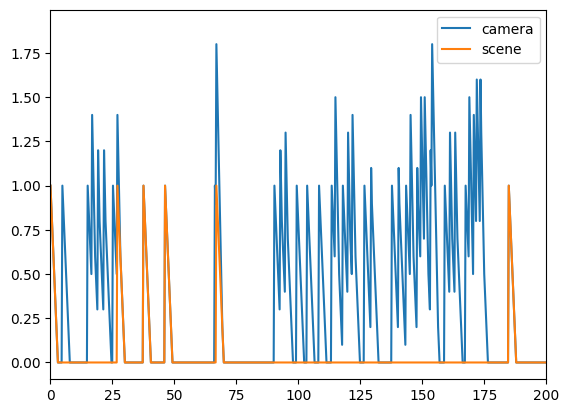

In [6]:
from matplotlib import pyplot as plt
plt.plot(times, camera_signal, label="camera")
plt.plot(times, scene_signal, label="scene")
plt.legend()
plt.xlim(0, 200)

In [ ]:
# np.save("camera_cuts.npy", camera_signal)
# np.save("scene_cuts.npy", scene_signal)